# [Kaggle] Pipeline: ATE + ASC & Error Analysis
Can chay NB01 va NB02 truoc de co models.


## 0. Setup


In [1]:
import subprocess, sys, os

# Install dependencies
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'underthesea', 'pytorch-crf', 'gensim'])

# =====================================================
# THAY DOI TEN DATASET DUOI DAY CHO DUNG
# =====================================================
DATA_DATASET = "UIT-ViSD4SA"      # Dataset chua train/dev/test.jsonl
SRC_DATASET  = "absa-src"       # Dataset chua folder src/

IS_KAGGLE = os.path.exists('/kaggle/input')
if IS_KAGGLE:
    DATA_DIR = '/kaggle/input/datasets/danghoang1302/uit-visd4sa'
    SAVE_DIR = '/kaggle/working/results'
    PREP_DIR = '/kaggle/working/preprocessed'

    # Kaggle mount: /kaggle/input/absa-src/src/{asc,ate,e2e,utils}
    # Copy sang working vi Kaggle input la read-only (relative imports can write cache)
    SRC_INPUT = '/kaggle/input/datasets/danghoang1302/absa-src'
    os.system(f'cp -r {SRC_INPUT}/src /kaggle/working/src')
    sys.path.insert(0, '/kaggle/working')

    print(f"KAGGLE | Data: {DATA_DIR}")
    print(f"KAGGLE | Src copied to: /kaggle/working/src/")
else:
    sys.path.insert(0, os.path.abspath(".."))
    DATA_DIR = os.path.join("..", "..", "data")
    SAVE_DIR = os.path.join("..", "..", "results")
    PREP_DIR = os.path.join("..", "..", "preprocessed")
    print(f"LOCAL mode")

# Verify
for fn in ['train.jsonl', 'dev.jsonl', 'test.jsonl']:
    assert os.path.exists(os.path.join(DATA_DIR, fn)), f"MISSING: {fn}"
print("All data files OK!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.9 MB/s eta 0:00:00
KAGGLE | Data: /kaggle/input/datasets/danghoang1302/uit-visd4sa
KAGGLE | Src copied to: /kaggle/working/src/
All data files OK!


## 1. Imports & Load


In [2]:
import torch, torch.nn as nn, numpy as np, pandas as pd
from torch.utils.data import DataLoader
from IPython.display import display

from src.utils.preprocess import (load_raw_data, segment_items, build_vocab, 
                                  train_w2v_embeddings, tokenize_baseline)
from src.ate.ate_dataset import ATEDataset, BIO_TAGS, TAG2ID, NUM_TAGS, ASPECTS
from src.ate.ate_model import build_ate_model
from src.asc.asc_model import build_asc_model
from src.utils.engine import predict_ate
from src.utils.metrics import bio_tags_to_spans, evaluate_spans_f1
from src.utils.visualization import plot_error_analysis

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

print("Building vocab & embeddings from scratch...")
train_items = segment_items(load_raw_data(os.path.join(DATA_DIR, "train.jsonl")))
dev_items = segment_items(load_raw_data(os.path.join(DATA_DIR, "dev.jsonl")))
test_items = segment_items(load_raw_data(os.path.join(DATA_DIR, "test.jsonl")))

all_texts = [item["text"] for item in train_items + dev_items + test_items]
word2idx = build_vocab(all_texts, min_freq=2, special_tokens=["[ASP]"])
VOCAB_SIZE = len(word2idx)
EMB_DIM = 150
emb_matrix = train_w2v_embeddings(all_texts, word2idx, emb_dim=EMB_DIM)
print(f"Vocab: {VOCAB_SIZE} | Emb: {EMB_DIM}d")

# =======================================================
# SỬA ĐƯỜNG DẪN LOAD MODEL TRỰC TIẾP Ở ĐÂY
# =======================================================
MODELS_DIR = "/kaggle/input/datasets/danghoang1302/models"

# ĐIỀN CHÍNH XÁC TÊN MODEL Ở ĐÂY (Nó sẽ tự tìm best_ate_TEN.pt và best_asc_TEN.pt)
best_ate = "BiGRU-CRF"   # Chú ý: Hãy sửa lại tên cho chuẩn với model ATE của bạn
best_asc = "BiGRU"       # Model ASC của bạn đã là BiGRU

try:
    print(f"Loading ATE: {best_ate} | ASC: {best_asc} từ {MODELS_DIR}")

    # Load ATE
    ate_type = best_ate.replace("-CRF", "")
    ate_model = build_ate_model(model_type=ate_type, vocab_size=VOCAB_SIZE, emb_dim=EMB_DIM,
        hidden_dim=256, num_tags=NUM_TAGS, n_layers=2, dropout=0.3).to(device)
    ate_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, f"best_ate_{best_ate}.pt"), map_location=device))
    ate_model.eval()

    # Load ASC
    asc_model = build_asc_model(model_type=best_asc, vocab_size=VOCAB_SIZE, emb_dim=EMB_DIM,
        hidden_dim=256, num_classes=3, n_layers=2, dropout=0.3).to(device)
    asc_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, f"best_asc_{best_asc}.pt"), map_location=device))
    asc_model.eval()
    
    print("✅ Models loaded successfully!")
    
except Exception as e:
    print(f"❌ Lỗi load model (Hãy kiểm tra lại tên model best_ate và best_asc): {e}")


Device: cuda
Building vocab & embeddings from scratch...
Training Word2Vec 150d...
Embedding Matrix ready. Hit: 6166/6169 (100.0%)
Vocab: 6169 | Emb: 150d
Loading ATE: BiGRU-CRF | ASC: BiGRU từ /kaggle/input/datasets/danghoang1302/models
✅ Models loaded successfully!


## 2. Pipeline Inference


In [3]:
MAX_LEN = 128
SENTIMENT_NAMES = {0: "POSITIVE", 1: "NEGATIVE", 2: "NEUTRAL"}

def pipeline_predict(text, ate_model, asc_model, word2idx, device):
    words = text.split()[:MAX_LEN]
    seq, length = tokenize_baseline(text, word2idx, MAX_LEN)
    seq_t = torch.tensor([seq], dtype=torch.long).to(device)
    mask_t = torch.zeros(1, MAX_LEN, dtype=torch.bool); mask_t[0, :length] = True
    mask_t = mask_t.to(device); lens_t = torch.tensor([length])

    with torch.no_grad():
        pred_tags = ate_model(seq_t, mask=mask_t, lens=lens_t)[0]
    spans = bio_tags_to_spans(pred_tags, BIO_TAGS, length)

    results = []
    for aspect_label, start_idx, end_idx in spans:
        aspect_text = " ".join(words[start_idx:end_idx])
        marked = " ".join(words[:start_idx]) + " [ASP] " + aspect_text + " [ASP] " + " ".join(words[end_idx:])
        asc_seq, _ = tokenize_baseline(marked.strip(), word2idx, MAX_LEN)
        asc_t = torch.tensor([asc_seq], dtype=torch.long).to(device)
        with torch.no_grad():
            sentiment_id = asc_model(asc_t).argmax(dim=1).item()
        results.append({"aspect": aspect_text, "category": aspect_label,
                         "sentiment": SENTIMENT_NAMES[sentiment_id],
                         "label": f"{aspect_label}#{SENTIMENT_NAMES[sentiment_id]}"})
    return results

# Full test set
print("Running pipeline on test set...")
all_true, all_pred = [], []
for item in test_items:
    true_set = set(label for _, _, label in item.get("labels", []))
    preds = pipeline_predict(item["text"], ate_model, asc_model, word2idx, device)
    pred_set = set(p["label"] for p in preds)
    all_true.append(true_set); all_pred.append(pred_set)

tp = sum(len(t & p) for t, p in zip(all_true, all_pred))
fp = sum(len(p - t) for t, p in zip(all_true, all_pred))
fn = sum(len(t - p) for t, p in zip(all_true, all_pred))
p = tp/(tp+fp) if tp+fp>0 else 0; r = tp/(tp+fn) if tp+fn>0 else 0
f1 = 2*p*r/(p+r) if p+r>0 else 0
print(f"\nPIPELINE RESULTS: P={p:.4f} R={r:.4f} F1={f1:.4f}")


Running pipeline on test set...

PIPELINE RESULTS: P=0.8312 R=0.7719 F1=0.8005


## 3. Error Analysis


Errors: 2483 (FN: 1472, FP: 1011)


,Text,Error_Type,Direction
0,máy sài rất êm_mượt mà_còn thắc_mắc iphone7 pl...,WRONG: DESIGN#POSITIVE,FP
1,sản_phẩm qua tệ sai mấy lời liên_tục sắc không...,MISSED: BATTERY#NEGATIVE,FN
2,sản_phẩm qua tệ sai mấy lời liên_tục sắc không...,MISSED: SER&ACC#NEGATIVE,FN
3,sản_phẩm qua tệ sai mấy lời liên_tục sắc không...,WRONG: CAMERA#NEGATIVE,FP
4,mình mua máy hôm 3/5 ở tgdđ nguyễn_thị_tú . nh...,MISSED: PERFORMANCE#NEUTRAL,FN
5,"sản_phẩm tốt_mượt và đáng số tiền , mà minh_th...",MISSED: GENERAL#POSITIVE,FN
6,mới mua 3 ngày máy củ đã qua sử_dụng với giá 8...,MISSED: SER&ACC#POSITIVE,FN
7,mới mua 3 ngày máy củ đã qua sử_dụng với giá 8...,MISSED: PRICE#NEUTRAL,FN
8,"máy_hình chưa chưa tới 1 gb , chỉ_tải vài ứng_...",MISSED: FEATURES#NEGATIVE,FN
9,"máy_hình chưa chưa tới 1 gb , chỉ_tải vài ứng_...",MISSED: STORAGE#NEGATIVE,FN


/kaggle/working/src/utils/visualization.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_counts.values, y=error_counts.index, palette='Reds_r', ax=ax)


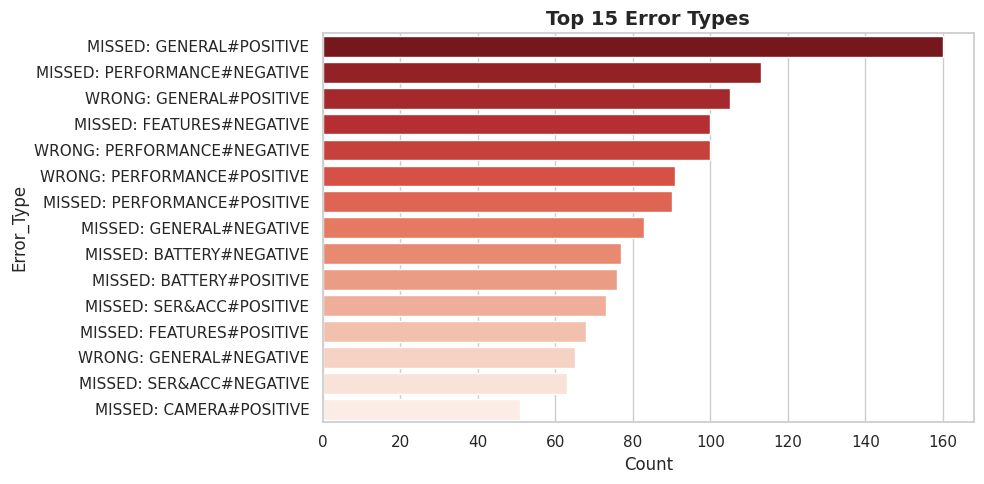

Pipeline F1: 0.8005 -> Saved!


In [4]:
errors = []
for i, (ts, ps) in enumerate(zip(all_true, all_pred)):
    for label in ts - ps:
        errors.append({"Text": test_items[i]["text"][:100],
            "Error_Type": f"MISSED: {label}", "Direction": "FN"})
    for label in ps - ts:
        errors.append({"Text": test_items[i]["text"][:100],
            "Error_Type": f"WRONG: {label}", "Direction": "FP"})

error_df = pd.DataFrame(errors)
print(f"Errors: {len(error_df)} (FN: {(error_df['Direction']=='FN').sum()}, FP: {(error_df['Direction']=='FP').sum()})")
display(error_df.head(15))
plot_error_analysis(error_df, top_n=15)

PIPE_DIR = os.path.join(SAVE_DIR, "pipeline"); os.makedirs(PIPE_DIR, exist_ok=True)
error_df.to_csv(os.path.join(PIPE_DIR, "error_analysis.csv"), index=False)
print(f"Pipeline F1: {f1:.4f} -> Saved!")
